<a href="https://colab.research.google.com/github/NigthDragon5000/BasicCoin/blob/master/CrossValHyper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cross Validation

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 14.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import optuna
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

In [ ]:

# Función objetivo que queremos minimizar
def objective(trial):
    x = trial.suggest_float("x", -10, 10)
    return (x - 2) ** 2  # Queremos que x sea lo más cercano posible a 2

# Crear el estudio
study = optuna.create_study(direction="minimize")

# Ejecutar la optimización
study.optimize(objective, n_trials=100)

# Resultados
print("Mejor valor de x:", study.best_params)
print("Mejor resultado:", study.best_value)

[I 2025-06-09 00:02:31,498] A new study created in memory with name: no-name-438f80cf-4847-444c-895c-f026e11b411c
[I 2025-06-09 00:02:31,509] Trial 0 finished with value: 47.180440870156275 and parameters: {'x': -4.868801996720846}. Best is trial 0 with value: 47.180440870156275.
[I 2025-06-09 00:02:31,514] Trial 1 finished with value: 16.04200802407866 and parameters: {'x': 6.00524756089791}. Best is trial 1 with value: 16.04200802407866.
[I 2025-06-09 00:02:31,519] Trial 2 finished with value: 62.33958855092778 and parameters: {'x': -5.895542321520908}. Best is trial 1 with value: 16.04200802407866.
[I 2025-06-09 00:02:31,522] Trial 3 finished with value: 12.722671418749451 and parameters: {'x': -1.5668853946755075}. Best is trial 3 with value: 12.722671418749451.
[I 2025-06-09 00:02:31,531] Trial 4 finished with value: 16.241207551163725 and parameters: {'x': 6.030038157531976}. Best is trial 3 with value: 12.722671418749451.
[I 2025-06-09 00:02:31,534] Trial 5 finished with value: 

Mejor valor de x: {'x': 1.9933572210163164}
Mejor resultado: 4.4126512626068456e-05


In [ ]:

# --- Generate synthetic dataset ---
X, y = make_classification(n_samples=1000, n_features=20,
                           n_informative=10, n_redundant=5,
                           random_state=42)

# Step 2: First split — train + temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,  # 40% goes to temp, 60% train
    random_state=42,
    stratify=y
)

# Step 3: Second split — validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,  # Half of 40% = 20% for validation, 20% for test
    random_state=42,
    stratify=y_temp
)

# Final split: 60% train, 20% val, 20% test
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (600, 20), Val: (200, 20), Test: (200, 20)


In [ ]:
# --- Define the objective function with CV ---
'''
def objective(trial):
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",  # use "gpu_hist" if GPU is available
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "lambda": trial.suggest_float("lambda", 1e-8, 10.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-8, 10.0, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "verbosity": 0
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    val_auc_scores = []
    train_auc_scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model = xgb.XGBClassifier(**params, use_label_encoder=False,
                  early_stopping_rounds=10, verbose=False)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)])

        y_train_pred = model.predict_proba(X_train)[:, 1]
        y_val_pred = model.predict_proba(X_val)[:, 1]

        train_auc = roc_auc_score(y_train, y_train_pred)
        val_auc = roc_auc_score(y_val, y_val_pred)

        train_auc_scores.append(train_auc)
        val_auc_scores.append(val_auc)

    avg_train_auc = np.mean(train_auc_scores)
    avg_val_auc = np.mean(val_auc_scores)
    overfit_gap = abs(avg_train_auc - avg_val_auc)

    return avg_val_auc, -overfit_gap  # Maximize val AUC, minimize overfitting
'''

'\ndef objective(trial):\n    params = {\n        "objective": "binary:logistic",\n        "eval_metric": "auc",\n        "tree_method": "hist",  # use "gpu_hist" if GPU is available\n        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),\n        "max_depth": trial.suggest_int("max_depth", 3, 12),\n        "min_child_weight": trial.suggest_float("min_child_weight", 1, 10),\n        "subsample": trial.suggest_float("subsample", 0.5, 1.0),\n        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),\n        "lambda": trial.suggest_float("lambda", 1e-8, 10.0, log=True),\n        "alpha": trial.suggest_float("alpha", 1e-8, 10.0, log=True),\n        "n_estimators": trial.suggest_int("n_estimators", 50, 300),\n        "verbosity": 0\n    }\n\n    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)\n\n    val_auc_scores = []\n    train_auc_scores = []\n\n    for train_idx, val_idx in skf.split(X, y):\n        X_train, X_val = X[tr

In [ ]:

def objective(trial):
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "lambda": trial.suggest_float("lambda", 1e-8, 10.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-8, 10.0, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "verbosity": 0
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_val_aucs = []
    cv_train_aucs = []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_vl = X_train[train_idx], X_train[val_idx]
        y_tr, y_vl = y_train[train_idx], y_train[val_idx]

        model = xgb.XGBClassifier(**params, use_label_encoder=False,
                                  early_stopping_rounds=10)

        model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)

        y_tr_pred = model.predict_proba(X_tr)[:, 1]
        y_vl_pred = model.predict_proba(X_vl)[:, 1]

        cv_train_aucs.append(roc_auc_score(y_tr, y_tr_pred))
        cv_val_aucs.append(roc_auc_score(y_vl, y_vl_pred))

    mean_cv_train_auc = np.mean(cv_train_aucs)
    mean_cv_val_auc = np.mean(cv_val_aucs)

    # Now train final model on full X_train and evaluate on external X_val:
    final_model = xgb.XGBClassifier(**params, use_label_encoder=False,
                                    early_stopping_rounds=10)
    final_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    y_train_pred_final = final_model.predict_proba(X_train)[:, 1]
    y_val_pred_final = final_model.predict_proba(X_val)[:, 1]

    final_train_auc = roc_auc_score(y_train, y_train_pred_final)
    final_val_auc = roc_auc_score(y_val, y_val_pred_final)

    overfit_gap = abs(final_train_auc - final_val_auc)

    return final_val_auc, -overfit_gap

In [ ]:
# --- Create study and optimize ---
study = optuna.create_study(directions=["maximize", "maximize"])
study.optimize(objective, n_trials=20)

# --- Print Pareto-optimal results ---
print("\nPareto-optimal trials with CV:")
for trial in study.best_trials:
    val_auc, neg_gap = trial.values
    print(f"AUC: {val_auc:.4f}, Overfit Gap: {-neg_gap:.4f}, Params: {trial.params}")

[I 2025-06-09 00:02:32,869] A new study created in memory with name: no-name-8d9989a3-8d3d-424d-98c4-eaef8b37187f
[I 2025-06-09 00:02:37,706] Trial 0 finished with values: [0.9328000000000001, -0.03264290857371421] and parameters: {'learning_rate': 0.06345272534919187, 'max_depth': 7, 'min_child_weight': 7.79854760718296, 'subsample': 0.5075557356188065, 'colsample_bytree': 0.9641981089718916, 'lambda': 4.921019858285207, 'alpha': 2.177010331693261e-06, 'n_estimators': 232}.
[I 2025-06-09 00:02:43,458] Trial 1 finished with values: [0.9675, -0.027766456286946073] and parameters: {'learning_rate': 0.09621389975560438, 'max_depth': 11, 'min_child_weight': 5.609563885743228, 'subsample': 0.8254532734429925, 'colsample_bytree': 0.9770189716953974, 'lambda': 0.0005127109089083583, 'alpha': 0.005023518707519068, 'n_estimators': 89}.
[I 2025-06-09 00:02:45,521] Trial 2 finished with values: [0.9619, -0.0318330548024357] and parameters: {'learning_rate': 0.10266431700150004, 'max_depth': 5, 'm


Pareto-optimal trials with CV:
AUC: 0.9438, Overfit Gap: 0.0072, Params: {'learning_rate': 0.014198825902687858, 'max_depth': 11, 'min_child_weight': 9.655588880221805, 'subsample': 0.6418033576159463, 'colsample_bytree': 0.9299109690769851, 'lambda': 9.643472980453449e-06, 'alpha': 0.013984194193613053, 'n_estimators': 58}
AUC: 0.9667, Overfit Gap: 0.0161, Params: {'learning_rate': 0.03998584017135863, 'max_depth': 4, 'min_child_weight': 7.029360105556059, 'subsample': 0.8601945516868779, 'colsample_bytree': 0.6412527017535035, 'lambda': 1.311705634186301e-05, 'alpha': 0.0002363723762219908, 'n_estimators': 174}
AUC: 0.9805, Overfit Gap: 0.0195, Params: {'learning_rate': 0.06715309980166, 'max_depth': 9, 'min_child_weight': 1.4185855996584422, 'subsample': 0.7533608296037742, 'colsample_bytree': 0.5985758066645175, 'lambda': 2.0091285446112503e-08, 'alpha': 0.00012034221162582108, 'n_estimators': 108}


In [ ]:
'''
import optuna.visualization as vis

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()
'''

'\nimport optuna.visualization as vis\n\nvis.plot_optimization_history(study).show()\nvis.plot_param_importances(study).show()\n'

In [ ]:
i=0
for trial in study.best_trials:
  i=i+1
  print(i)

1
2
3


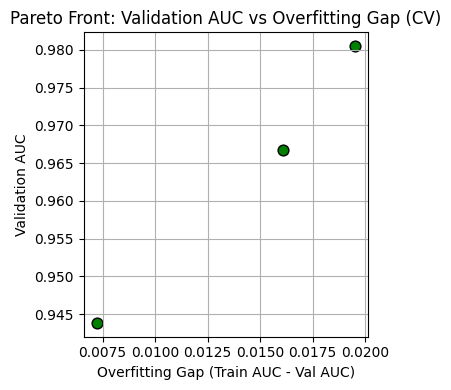

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Extract best trials' values ---
values = np.array([trial.values for trial in study.best_trials])
val_auc = values[:, 0]
overfit_gap = -values[:, 1]  # negate since we minimized -gap

# --- Plot ---
plt.figure(figsize=(4, 4))
plt.scatter(overfit_gap, val_auc, c="green", s=60, edgecolor="k")
plt.title("Pareto Front: Validation AUC vs Overfitting Gap (CV)")
plt.xlabel("Overfitting Gap (Train AUC - Val AUC)")
plt.ylabel("Validation AUC")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
dat=pd.DataFrame(values)
dat.columns=['Gini','Overfitting']
dat['Overfitting'] = -dat['Overfitting']
dat.sort_values('Gini')

,Gini,Overfitting
0,0.94385,0.007214
1,0.96670,0.016088
2,0.98050,0.019500


In [ ]:
print("\n--- Pareto Front Hyperparameters ---")
for i, trial in enumerate(study.best_trials):
    val_auc, neg_gap = trial.values
    gap = -neg_gap  # reverse back to get actual overfitting gap

    print(f"\nPoint {i+1}:")
    print(f"  Validation AUC: {val_auc:.4f}")
    print(f"  Overfitting Gap: {gap:.4f}")
    print("  Hyperparameters:")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")


--- Pareto Front Hyperparameters ---

Point 1:
  Validation AUC: 0.9438
  Overfitting Gap: 0.0072
  Hyperparameters:
    learning_rate: 0.014198825902687858
    max_depth: 11
    min_child_weight: 9.655588880221805
    subsample: 0.6418033576159463
    colsample_bytree: 0.9299109690769851
    lambda: 9.643472980453449e-06
    alpha: 0.013984194193613053
    n_estimators: 58

Point 2:
  Validation AUC: 0.9667
  Overfitting Gap: 0.0161
  Hyperparameters:
    learning_rate: 0.03998584017135863
    max_depth: 4
    min_child_weight: 7.029360105556059
    subsample: 0.8601945516868779
    colsample_bytree: 0.6412527017535035
    lambda: 1.311705634186301e-05
    alpha: 0.0002363723762219908
    n_estimators: 174

Point 3:
  Validation AUC: 0.9805
  Overfitting Gap: 0.0195
  Hyperparameters:
    learning_rate: 0.06715309980166
    max_depth: 9
    min_child_weight: 1.4185855996584422
    subsample: 0.7533608296037742
    colsample_bytree: 0.5985758066645175
    lambda: 2.0091285446112503e-0

In [ ]:
# Plot history of the first objective: Validation AUC
optuna.visualization.plot_optimization_history(
    study, target=lambda t: t.values[0], target_name="Validation AUC"
).show()


In [ ]:

# Plot history of the second objective: Overfitting gap (negated, so we reverse sign)
optuna.visualization.plot_optimization_history(
    study, target=lambda t: -t.values[1], target_name="Overfitting Gap"
).show()

In [ ]:
optuna.visualization.plot_pareto_front(
    study,
    target_names=["Validation AUC", "Overfitting Gap"]
).show()

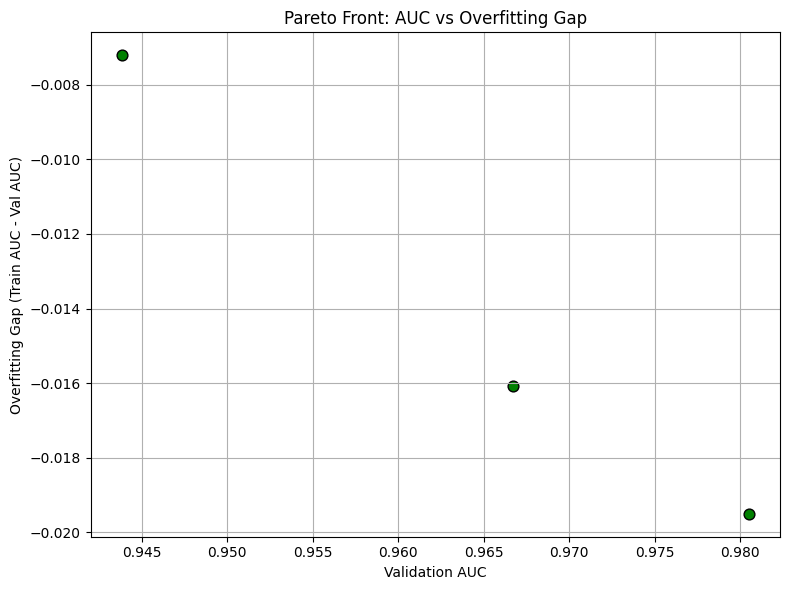

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

val_aucs = []
overfit_gaps = []

for trial in study.best_trials:
    val_auc, neg_gap = trial.values
    val_aucs.append(val_auc)
    overfit_gaps.append(neg_gap)

plt.figure(figsize=(8, 6))
plt.scatter(val_aucs, overfit_gaps, c='green', s=60, edgecolor='k')
plt.xlabel("Validation AUC")
plt.ylabel("Overfitting Gap (Train AUC - Val AUC)")
plt.title("Pareto Front: AUC vs Overfitting Gap")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
best_trial = max(study.best_trials, key=lambda t: t.values[0])
best_params = best_trial.params
print("Best Hyperparameters based on Validation AUC:\n", best_params)

Best Hyperparameters based on Validation AUC:
 {'learning_rate': 0.06715309980166, 'max_depth': 9, 'min_child_weight': 1.4185855996584422, 'subsample': 0.7533608296037742, 'colsample_bytree': 0.5985758066645175, 'lambda': 2.0091285446112503e-08, 'alpha': 0.00012034221162582108, 'n_estimators': 108}


# Boostrapping

In [ ]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score

# Train model on full training set
model = xgb.XGBClassifier(
    **best_params,
    use_label_encoder=False,
    eval_metric="auc",
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=10
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)] , verbose = False)

# Evaluate on X_val
y_pred_proba = model.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, y_pred_proba)
print(f"Validation AUC on hold-out set: {val_auc:.4f}")

Validation AUC on hold-out set: 0.9707


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[00:02:56] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




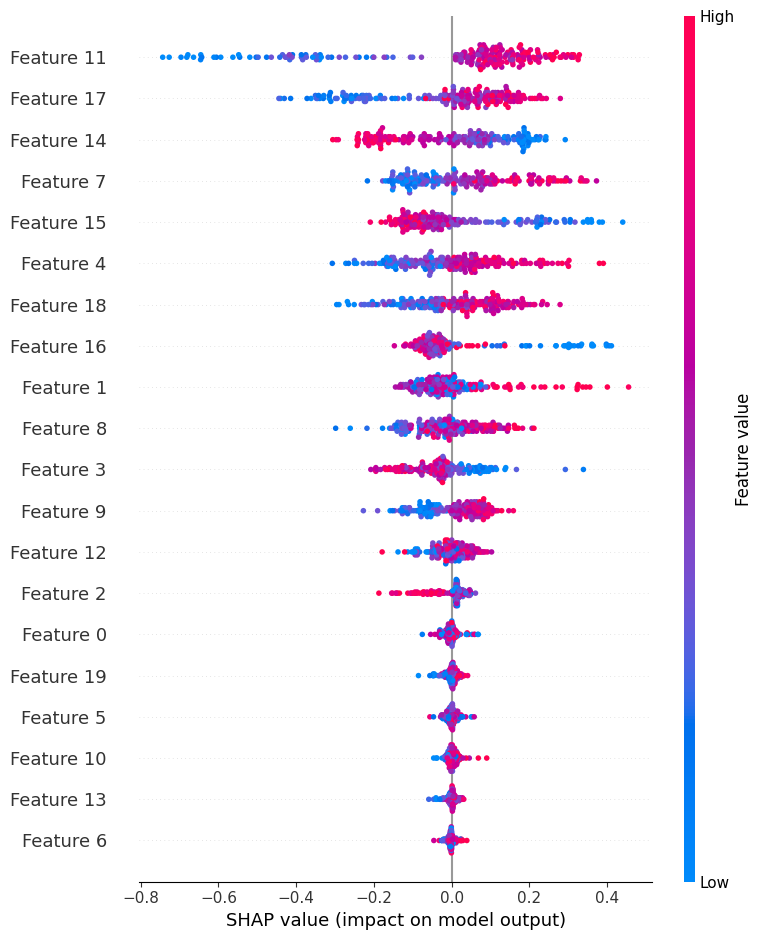

In [ ]:
import shap

# Use TreeExplainer (fast for XGBoost)
explainer = shap.Explainer(model)

# Compute SHAP values on validation set
shap_values = explainer(X_val)

# Plot feature importance summary
shap.summary_plot(shap_values, X_val)

In [ ]:
import pandas as pd
import numpy as np

# SHAP values object contains .values (samples x features) and .feature_names
shap_array = np.abs(shap_values.values)  # take absolute values
#feature_names = X.columns  # or shap_values.feature_names

# Compute mean absolute SHAP value for each feature
mean_shap = shap_array.mean(axis=0)

# Create a DataFrame
shap_importance_df = pd.DataFrame({
  #  "Feature": feature_names,
    "Mean |SHAP value|": mean_shap
}).sort_values(by="Mean |SHAP value|", ascending=False)

# Display top features
print(shap_importance_df)

    Mean |SHAP value|
11           0.214285
17           0.134930
14           0.125810
7            0.111895
15           0.110723
4            0.103886
18           0.097772
16           0.083488
1            0.072247
8            0.069619
3            0.066099
9            0.063003
12           0.034534
2            0.034010
0            0.012293
19           0.010074
5            0.009406
10           0.008957
13           0.008071
6            0.006518


In [ ]:
import shap
import pandas as pd
import numpy as np
from tqdm import tqdm

n_bootstrap = 100  # You can increase this for more precision
#X_array = X.values
X_pd = pd.DataFrame(X_val)
X_array= X_pd.values
n_samples = X_pd.shape[0]
n_features = X_pd.shape[1]

# Container for bootstrap SHAP means
bootstrap_shap = []

explainer = shap.Explainer(model)

for _ in tqdm(range(n_bootstrap)):
    # Sample rows with replacement
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    X_sample = X_pd.iloc[indices]

    # Compute SHAP values
    shap_vals = explainer(X_sample)

    # Store mean absolute SHAP per feature
    mean_shap_vals = np.abs(shap_vals.values).mean(axis=0)
    bootstrap_shap.append(mean_shap_vals)



100%|██████████| 100/100 [00:03<00:00, 25.62it/s]


In [ ]:
# Convert to DataFrame
bootstrap_df = pd.DataFrame(bootstrap_shap, columns=X_pd.columns)

In [ ]:
summary_stats = bootstrap_df.describe(percentiles=[.05, .25, .5, .75, .95]).T
summary_stats = summary_stats[["mean", "std", "5%", "25%", "50%", "75%", "95%"]]
print(summary_stats)

        mean       std        5%       25%       50%       75%       95%
0   0.012182  0.000930  0.010750  0.011596  0.012159  0.012695  0.013788
1   0.071742  0.005079  0.064355  0.068214  0.071606  0.075634  0.079330
2   0.033949  0.002278  0.030314  0.032618  0.033901  0.035336  0.037965
3   0.065563  0.003900  0.060165  0.063026  0.064899  0.067853  0.072783
4   0.103415  0.005648  0.093636  0.100219  0.103298  0.106520  0.113436
5   0.009551  0.000657  0.008518  0.009080  0.009611  0.010071  0.010543
6   0.006480  0.000596  0.005540  0.006061  0.006524  0.006889  0.007310
7   0.112548  0.006336  0.102125  0.108747  0.111826  0.116703  0.122516
8   0.069502  0.004280  0.063199  0.066391  0.069507  0.072178  0.076790
9   0.063144  0.002901  0.057935  0.061286  0.063052  0.065553  0.067676
10  0.008874  0.000814  0.007671  0.008295  0.008763  0.009422  0.010178
11  0.214801  0.012310  0.195998  0.207091  0.213868  0.220470  0.235502
12  0.034563  0.001926  0.031450  0.033488  0.03434

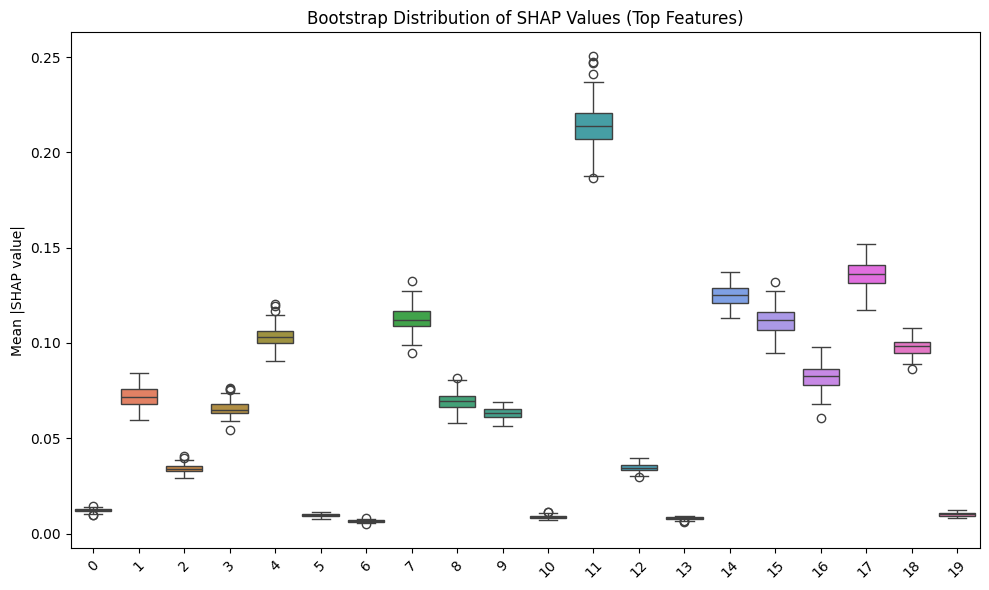

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot for top N most important features
top_features = bootstrap_df.mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
sns.boxplot(data=bootstrap_df[top_features])
plt.xticks(rotation=45)
plt.ylabel("Mean |SHAP value|")
plt.title("Bootstrap Distribution of SHAP Values (Top Features)")
plt.tight_layout()
plt.show()

In [ ]:
np.array([11, 14,  7, 17, 15,  2, 18,  3,  1, 16,  9, 12,  8,  4])

array([11, 14,  7, 17, 15,  2, 18,  3,  1, 16,  9, 12,  8,  4])

In [ ]:
bootstrap_df.mean()

,0
0,0.012182
1,0.071742
2,0.033949
3,0.065563
4,0.103415
5,0.009551
6,0.006480
7,0.112548
8,0.069502
9,0.063144


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import shap
from tqdm import tqdm

# Step 1: Split the data
#X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Step 2: Compute SHAP on full data (or just X_train if you prefer)

#explainer = shap.Explainer(model, X_val)
#shap_values = explainer(X_val)


mean_shap = bootstrap_df.mean()
percentile_1_per_feature = np.percentile(bootstrap_df, 5,axis=0)
shap_importance_df = pd.DataFrame({
    "Feature": X_pd.columns,
    "Mean |SHAP|": mean_shap,
    "Percentile 5":  percentile_1_per_feature
}).sort_values(by="Mean |SHAP|", ascending=False)


In [ ]:
shap_importance_df['Percentile 5'].max()

0.195997953414917

In [ ]:
shap_importance_df

,Feature,Mean |SHAP|,Percentile 5
11,11,0.214801,0.195998
17,17,0.136178,0.125727
14,14,0.125347,0.116975
7,7,0.112548,0.102125
15,15,0.111606,0.100927
4,4,0.103415,0.093636
18,18,0.098056,0.090433
16,16,0.082153,0.072306
1,1,0.071742,0.064355
8,8,0.069502,0.063199


In [ ]:
best_params

{'learning_rate': 0.06715309980166,
 'max_depth': 9,
 'min_child_weight': 1.4185855996584422,
 'subsample': 0.7533608296037742,
 'colsample_bytree': 0.5985758066645175,
 'lambda': 2.0091285446112503e-08,
 'alpha': 0.00012034221162582108,
 'n_estimators': 108}

In [ ]:

X_train = pd.DataFrame(X_train)
X_val = pd.DataFrame(X_val)
y_train = np.array(y_train).ravel()
y_val = np.array(y_val).ravel()


In [ ]:
'''
print(X_train[selected_features].shape)
print(X_val[selected_features].shape)
print(y_train.shape)
print(y_val.shape)
'''

'\nprint(X_train[selected_features].shape)\nprint(X_val[selected_features].shape)\nprint(y_train.shape)\nprint(y_val.shape)\n'

In [ ]:

# Step 3: Test different SHAP cutoffs
cutoffs = np.arange(0, 0.48, 0.01)
results = []
features_by_cutoff = {}

for cutoff in tqdm(cutoffs):
    #selected_features = shap_importance_df[shap_importance_df["Mean |SHAP|"] >= cutoff]["Feature"].values
    selected_features = shap_importance_df[shap_importance_df["Percentile 5"] >= cutoff]["Feature"].values

    print(selected_features)

    if len(selected_features) == 0:
        continue  # skip if no features pass the threshold

    # Store selected features for this cutoff
    features_by_cutoff[cutoff] = selected_features

    #dtrain = xgb.DMatrix(X_train[selected_features], label=y_train)
    #dval = xgb.DMatrix(X_val[selected_features], label=y_val)

    #evallist = [(dtrain, "train"), (dval, "eval")]

    #model = xgb.train(params, dtrain, num_boost_round=1000, early_stopping_rounds=30, evals=evallist, verbose_eval=False)

    '''
    model = xgb.XGBClassifier(
    **best_params,
    use_label_encoder=False,
    eval_metric="auc",
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=10
    )

    model.fit(X_train, y_train, eval_set=[(X_val, y_val)] , verbose = False)

    # Evaluate on X_val
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    print(y_pred_proba)
    val_auc = roc_auc_score(y_val, y_pred_proba)
    print(f"Validation AUC on hold-out set: {val_auc:.4f}")
    '''

    model = xgb.XGBClassifier(
    **best_params,
    use_label_encoder=False,
    eval_metric="auc",
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=10,
    verbose=False
    )


    model.fit(
        X_train[selected_features],y_train,
        eval_set=[(X_val[selected_features], y_val)],

        )


    # Get predictions
    train_preds = model.predict_proba(X_train[selected_features])[:, 1]
    print(train_preds)
    val_preds = model.predict_proba(X_val[selected_features])[:, 1]

    # Compute Gini
    auc_train = roc_auc_score(y_train, train_preds)
    auc_val = roc_auc_score(y_val, val_preds)

    gini_train = 2 * auc_train - 1
    gini_val = 2 * auc_val - 1
    overfit = auc_train - auc_val

    results.append({
        "Cutoff": cutoff,
        "N_Features": len(selected_features),
        "Gini_Train": gini_train,
        "Gini_Val": gini_val,
        "Overfit": overfit,
        "Auc Val": auc_val
    })



  0%|          | 0/48 [00:00<?, ?it/s]

[11 17 14  7 15  4 18 16  1  8  3  9 12  2  0 19  5 10 13  6]
[0]	validation_0-auc:0.86205
[1]	validation_0-auc:0.89310
[2]	validation_0-auc:0.92340
[3]	validation_0-auc:0.93320
[4]	validation_0-auc:0.93310
[5]	validation_0-auc:0.94430
[6]	validation_0-auc:0.94070
[7]	validation_0-auc:0.94210
[8]	validation_0-auc:0.94630
[9]	validation_0-auc:0.94820
[10]	validation_0-auc:0.95130
[11]	validation_0-auc:0.95010
[12]	validation_0-auc:0.95180
[13]	validation_0-auc:0.95590
[14]	validation_0-auc:0.95790
[15]	validation_0-auc:0.95510
[16]	validation_0-auc:0.95530
[17]	validation_0-auc:0.95650
[18]	validation_0-auc:0.95820
[19]	validation_0-auc:0.95860
[20]	validation_0-auc:0.96030
[21]	validation_0-auc:0.95870
[22]	validation_0-auc:0.96030
[23]	validation_0-auc:0.95790
[24]	validation_0-auc:0.96060


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[00:03:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder", "verbose" } are not used.




[25]	validation_0-auc:0.96190
[26]	validation_0-auc:0.96080
[27]	validation_0-auc:0.96400
[28]	validation_0-auc:0.96320
[29]	validation_0-auc:0.96390
[30]	validation_0-auc:0.96560
[31]	validation_0-auc:0.96610
[32]	validation_0-auc:0.96590
[33]	validation_0-auc:0.96600
[34]	validation_0-auc:0.96600
[35]	validation_0-auc:0.96540
[36]	validation_0-auc:0.96600
[37]	validation_0-auc:0.96510
[38]	validation_0-auc:0.96550
[39]	validation_0-auc:0.96550
[40]	validation_0-auc:0.96700
[41]	validation_0-auc:0.96740
[42]	validation_0-auc:0.96590
[43]	validation_0-auc:0.96550
[44]	validation_0-auc:0.96650
[45]	validation_0-auc:0.96650
[46]	validation_0-auc:0.96600
[47]	validation_0-auc:0.96680
[48]	validation_0-auc:0.96720
[49]	validation_0-auc:0.96610
[50]	validation_0-auc:0.96540
[0.12394864 0.88528574 0.08725954 0.93915075 0.6368065  0.05019509
 0.86043173 0.814247   0.94997865 0.08641318 0.06485971 0.8974115
 0.91585    0.9441778  0.06828161 0.05020339 0.04378423 0.08420175
 0.11596688 0.070247

  2%|▏         | 1/48 [00:00<00:17,  2.64it/s]

...

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[00:03:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder", "verbose" } are not used.




[0.49536142 0.49957514 0.48073497 0.519887   0.48297003 0.4695694
 0.4878499  0.5232387  0.49536142 0.4695694  0.51150167 0.50870425
 0.51026386 0.51026386 0.51150167 0.51749176 0.51150167 0.4695694
 0.5217493  0.47794124 0.46956986 0.51026386 0.51026386 0.49831375
 0.48073497 0.49957514 0.49957514 0.51749176 0.49471617 0.51026386
 0.51026386 0.51749176 0.49957514 0.51150167 0.52445704 0.5079045
 0.51026386 0.5183632  0.5142969  0.51026386 0.51026386 0.51026386
 0.4844609  0.51026386 0.5079045  0.5031101  0.48872194 0.50870425
 0.5183632  0.5079045  0.51150167 0.47794124 0.52445704 0.51026386
 0.48297003 0.49957514 0.5217493  0.49536142 0.51026386 0.49191883
 0.5270661  0.5217493  0.47794124 0.5031101  0.47794124 0.52445704
 0.49536142 0.5031101  0.4844609  0.5270661  0.52826184 0.4878499
 0.5079045  0.46956986 0.5142969  0.4695694  0.5270661  0.519887
 0.47794124 0.51026386 0.49957514 0.46956986 0.48297003 0.50311077
 0.4695694  0.49957514 0.4878499  0.5183632  0.49471617 0.49957514
 

 42%|████▏     | 20/48 [00:05<00:03,  7.13it/s]

[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]


100%|██████████| 48/48 [00:05<00:00,  9.44it/s]


In [ ]:
# Step 4: Compile results
results_df = pd.DataFrame(results)
print(results_df)

    Cutoff  N_Features  Gini_Train  Gini_Val   Overfit  Auc Val
0     0.00          20    1.000000    0.9348  0.032600  0.96740
1     0.01          15    0.999933    0.9538  0.023067  0.97690
2     0.02          14    0.999911    0.9498  0.025056  0.97490
3     0.03          14    0.999911    0.9498  0.025056  0.97490
4     0.04          12    0.999800    0.9288  0.035500  0.96440
5     0.05          12    0.999800    0.9288  0.035500  0.96440
6     0.06          11    0.999844    0.9234  0.038222  0.96170
7     0.07           8    0.999978    0.9010  0.049489  0.95050
8     0.08           7    1.000000    0.9326  0.033700  0.96630
9     0.09           7    1.000000    0.9326  0.033700  0.96630
10    0.10           5    0.999867    0.8540  0.072933  0.92700
11    0.11           3    0.919819    0.5258  0.197009  0.76290
12    0.12           2    0.817603    0.3398  0.238902  0.66990
13    0.13           1    0.439386    0.2523  0.093543  0.62615
14    0.14           1    0.439386    0.

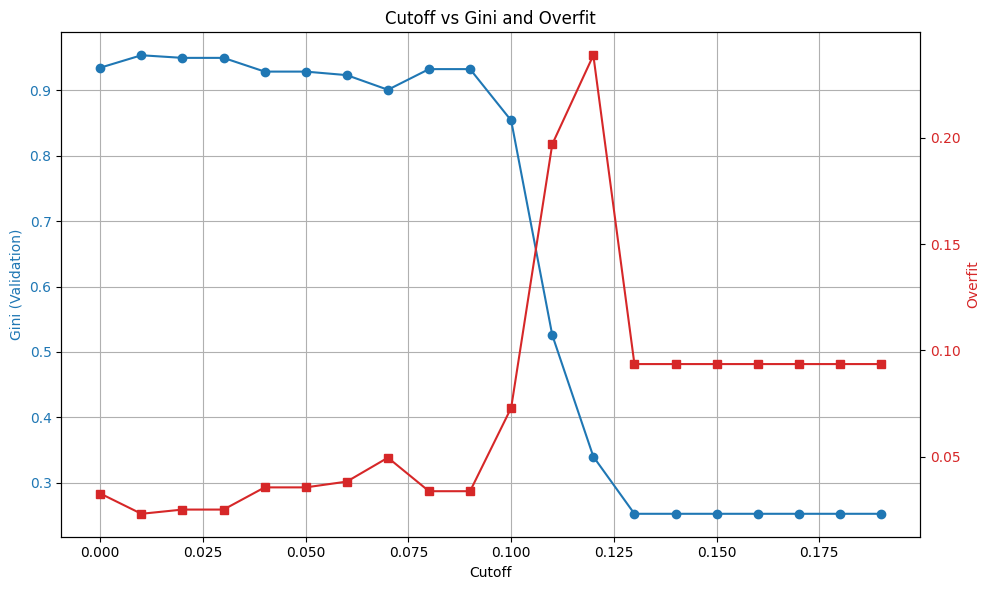

In [ ]:
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df
# and has columns: 'Cutoff', 'Overfit', 'Gini_val'

fig, ax1 = plt.subplots(figsize=(10, 6))

# First Y-axis: Gini_val
color1 = 'tab:blue'
ax1.set_xlabel('Cutoff')
ax1.set_ylabel('Gini (Validation)', color=color1)
ax1.plot(results_df['Cutoff'], results_df['Gini_Val'], color=color1, marker='o', label='Gini (Validation)')
ax1.tick_params(axis='y', labelcolor=color1)

# Second Y-axis: Overfit
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color2 = 'tab:red'
ax2.set_ylabel('Overfit', color=color2)
ax2.plot(results_df['Cutoff'], results_df['Overfit'], color=color2, marker='s', label='Overfit')
ax2.tick_params(axis='y', labelcolor=color2)

# Optional: grid and title
plt.title('Cutoff vs Gini and Overfit')
ax1.grid(True)

# Show plot
plt.tight_layout()
plt.show()


In [ ]:
len(features_by_cutoff[0.03])

14

In [ ]:
features_by_cutoff[0.03]

array([11, 17, 14,  7, 15,  4, 18, 16,  1,  8,  3,  9, 12,  2])

In [ ]:
optuna.visualization.plot_param_importances(study)

In [ ]:
optuna.visualization.plot_parallel_coordinate(study,
                                              target=lambda t: -t.values[1], target_name="Overfitting Gap")


In [ ]:
optuna.visualization.plot_contour(study,
                                  target=lambda t: -t.values[1], target_name="Overfitting Gap")